# 随机森林

想象一下，你正在参加一个重要的知识竞赛，面对一个难题，你是更相信一位顶尖专家的判断，还是更相信由 100 位水平不错的选手投票得出的结果？在大多数情况下，集体的智慧往往能弥补个人的偏见和局限，从而做出更稳定、更准确的决策。

在机器学习的世界里，随机森林（Random Forest） 正是这种集体智慧思想的杰出代表。它通过构建大量的决策树，并让它们共同投票来做出预测，从而成为最强大、最受欢迎的机器学习算法之一。



## 什么是随机森林？

随机森林 是一种基于集成学习（Ensemble Learning）的机器学习算法。它的核心思想非常简单：三个臭皮匠，顶个诸葛亮。

- 森林： 指的是由多棵 决策树（Decision Tree） 组成的集合。
- 随机： 指的是在构建每一棵决策树时，算法会引入两种随机性，确保每棵树都与众不同。

最终，对于分类任务，森林通过 投票（多数决） 给出结果；对于回归任务，则通过 取平均值 给出结果。

## 核心思想 : Bagging 与 随机性
随机森林的成功建立在两大基石之上：

#### Bagging（Bootstrap Aggregating）：

- Bootstrap（自助采样）： 从原始训练数据集中有放回地随机抽取样本，生成多个不同的子训练集。这意味着同一个样本可能在一个子集中出现多次，而另一个样本可能一次都不出现。
- Aggregating（聚合）： 用每个子训练集独立训练一棵决策树，最后将所有树的结果聚合起来（投票或平均）。
![alt text](1f9cadae-8e3b-42ad-90a4-89d3aa863058.png)

#### 特征随机性：
- 在构建每棵树的每个节点进行分裂时，算法不会考虑所有的特征，而是从全部特征中随机选取一个子集，然后从这个子集中选择最优分裂特征。
- 这进一步增强了树与树之间的差异性，让森林看到问题的不同侧面。


简单来说，随机森林通过让每棵树在略有不同的数据和特征视角下进行训练，创造了一个多样化的专家委员会。 即使其中一些树犯了错误，其他正确的树也能通过投票将其纠正，从而获得比单棵决策树更稳定、更强大的性能。


------

## 算法流程与关键参数

#### 随机森林的工作步骤
让我们通过一个流程图来清晰地看透它的工作过程：  
![alt text](ml-random-forest-runoob-scaled.png)

#### 关键参数解析

| 参数名 | 含义 | 典型值 / 影响 | 通俗解释 |
|---|---|---|---|
| `n_estimators` | 森林中决策树的数量 | 默认 `100`。值越大，模型通常越稳定、性能越好，但计算成本也越高。 | “委员会的人数”。人越多，决策通常越可靠，但开会时间也更长。 |
| `max_depth` | 单棵决策树的最大深度 | 默认 `None`（不限制）。限制深度可以防止过拟合，使模型更简单。 | “限制每个人的发言时间”。防止某个专家（树）钻牛角尖，过度关注训练数据细节。 |
| `max_features` | 寻找最佳分裂时考虑的特征数 | 可以是整数、浮点数或 `'auto'` / `'sqrt'`。这是引入“特征随机性”的关键参数。 | “每次讨论只随机看几个方面”。确保每棵树从不同角度分析问题，增加多样性。 |
| `min_samples_split` | 节点分裂所需的最小样本数 | 默认 `2`。值越大，树生长越保守，越不容易过拟合。 | “一个小组至少要有几个人才能继续分组讨论”。避免因为一两个样本就创建新规则。 |
| `min_samples_leaf` | 叶节点所需的最小样本数 | 默认 `1`。值越大，模型越平滑。 | “最终结论至少需要基于几个案例”。确保每个结论都有一定的数据支撑。 |
| `bootstrap` | 是否使用 Bootstrap 采样 | 默认 `True`。如果设为 `False`，将使用整个数据集训练每棵树，但会失去一部分随机性。 | “是否允许一个人重复发言”。开启就是 Bagging 的精髓。 |

-------

## 实战演练

In [1]:
# 示例 1 : 基础分类任务

# 导入必要的库
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. 加载数据
iris = load_iris()
X = iris.data  # 特征：花萼长度、宽度，花瓣长度、宽度
y = iris.target # 标签：三种鸢尾花

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 创建随机森林分类器
# 这里我们设置 100 棵树，并限制最大深度为 5
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 4. 训练模型
rf_clf.fit(X_train, y_train)

# 5. 在测试集上进行预测
y_pred = rf_clf.predict(X_test)

# 6. 评估模型性能
print("测试集准确率：", accuracy_score(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

测试集准确率： 1.0

分类报告：
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK U

测试集准确率： 1.0

分类报告：
特征重要性排序：
                  特征       重要性
3   petal width (cm)  0.436574
2  petal length (cm)  0.417326
0  sepal length (cm)  0.104614
1   sepal width (cm)  0.041486


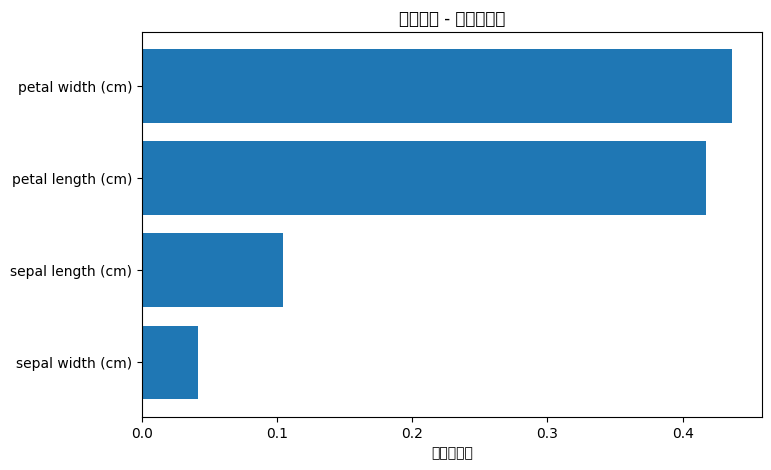

In [2]:
# 示例 2 : 特征重要性分析
# 随机森林还有一个强大功能：评估每个特征对预测的贡献程度。

# 导入必要的库
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------- 设置中文字体 start --------------------------
plt.rcParams['font.sans-serif'] = [
    # Windows 优先
    'SimHei', 'Microsoft YaHei',
]
# 修复负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# -------------------------- 设置中文字体 end --------------------------

# 1. 加载数据
iris = load_iris()
X = iris.data  # 特征：花萼长度、宽度，花瓣长度、宽度
y = iris.target # 标签：三种鸢尾花

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 创建随机森林分类器
# 这里我们设置 100 棵树，并限制最大深度为 5
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 4. 训练模型
rf_clf.fit(X_train, y_train)

# 5. 在测试集上进行预测
y_pred = rf_clf.predict(X_test)

# 6. 评估模型性能
print("测试集准确率：", accuracy_score(y_test, y_pred))
print("\n分类报告：")


# 获取特征重要性
feature_importances = rf_clf.feature_importances_
features = iris.feature_names

# 创建 DataFrame 便于查看
importance_df = pd.DataFrame({
    '特征': features,
    '重要性': feature_importances
}).sort_values('重要性', ascending=False)

print("特征重要性排序：")
print(importance_df)

# 可视化
plt.figure(figsize=(8, 5))
plt.barh(importance_df['特征'], importance_df['重要性'])
plt.xlabel('特征重要性')
plt.title('随机森林 - 特征重要性')
plt.gca().invert_yaxis() # 让最重要的特征显示在顶部
plt.show()

------

## 四 . 优点 , 缺点与应用场景
#### 优点
- 高准确率： 集成学习通常能取得当前数据下顶尖的性能。
- 抗过拟合能力强： 得益于 Bagging 和随机特征选择，即使不剪枝，也不容易过拟合。
- 对数据要求友好： 能处理数值型和类别型特征，不需要特征缩放（如归一化）。
- 提供特征重要性： 内置的特征评估是宝贵的副产品。
- 并行化容易： 每棵树的训练是独立的，可以轻松并行加速。
#### 缺点
- 模型可解释性差： 成百上千棵树组成的"黑箱"，比单棵决策树难解释得多。
- 训练和预测速度较慢： 树的数量多时，需要更多的计算资源和时间。
- 内存占用大： 需要存储整个森林的所有树结构。
#### 典型应用场景
- 分类问题： 如垃圾邮件识别、疾病诊断、图像分类。
- 回归问题： 如房价预测、销售额预测。
- 特征选择： 利用其输出的特征重要性进行特征筛选。
- 缺失值处理： 随机森林有较好的处理缺失值的天然能力。